In [1]:
import os
from dotenv import load_dotenv
import aisuite as ai

load_dotenv()
openai_api_key = os.getenv("OPENAI_API_KEY")
client = ai.Client()

# Building my first tool

In [ ]:
from datetime import datetime

# Tool to get current time
def get_current_time():
    return datetime.now().strftime("%H:%M:%S")

In [6]:
get_current_time()

'17:47:32'

In [ ]:
# Calling the model
response = client.chat.completions.create(
    model="openai:gpt-4o",
    messages=[
        {
            "role":"user",
            "content":"What time is it ?",
        }
    ],
    tools=[get_current_time],
    max_turns=5
)

print(response.choices[0].message.content)

The current time is 17:51:20.


# Manually defining tools

In [ ]:
import json

# Defining tool using json schema
tools = [
    {
        "type":"function",
        "function":{
            "name":"get_current_time",
            "description": "Returns the current time as a string",
            "parameters": {}
        }
    }
]

messages = [
        {
            "role":"user",
            "content":"What time is it ?",
        }
]

# Calling the model
response = client.chat.completions.create(
    model="openai:gpt-4o",
    messages=messages,
    tools=tools,
)

# Inspecting the json
print(json.dumps(response.model_dump(), indent=2, default=str))

{
  "id": "chatcmpl-DVzCyzAfT1XiNITuNkBtvWQRtCF04",
  "choices": [
    {
      "finish_reason": "tool_calls",
      "index": 0,
      "logprobs": null,
      "message": {
        "content": null,
        "refusal": null,
        "role": "assistant",
        "annotations": [],
        "audio": null,
        "function_call": null,
        "tool_calls": [
          {
            "id": "call_3yxCMAKnaPLSrFQd9OpwKczg",
            "function": {
              "arguments": "{}",
              "name": "get_current_time"
            },
            "type": "function"
          }
        ]
      }
    }
  ],
  "created": 1776515824,
  "model": "gpt-4o-2024-08-06",
  "object": "chat.completion",
  "service_tier": "default",
  "system_fingerprint": "fp_2608ccf94f",
  "usage": {
    "completion_tokens": 11,
    "prompt_tokens": 45,
    "total_tokens": 56,
    "completion_tokens_details": {
      "accepted_prediction_tokens": 0,
      "audio_tokens": 0,
      "reasoning_tokens": 0,
      "rejected_pr

#### In the above response from the LLM, notice that in the response we can see tool_calls under "message". This response from the LLM is saying that the LLM now wants to call a tool, specifically "get_current_time" 

In [ ]:
# Creating a condition in case tool_calls is in response object
if response.choices[0].message.tool_calls:
    # Pull out the specific tool metadata from the response
    tool_call = response.choices[0].message.tool_calls[0]
    args = json.loads(tool_call.function.arguments)
    
    # Running the tool locally
    tool_result = get_current_time()
    
    # Appending the result to the messages list
    messages.append(response.choices[0].message)
    messages.append({
        "role":"tool",
        "tool_call_id":tool_call.id,
        "content": str(tool_result)
    })
    
    # Sending the new list of messages back to the LLM 
    response2 = client.chat.completions.create(
        model="openai:gpt-4o",
        messages=messages,
        tools=tools,
    )
    
    print(response2.choices[0].message.content)

The current time is 18:09:52.


# Giving the LLM more tools

In [ ]:
import requests

# Weather tool
def get_weather_from_ip():
    lat, lon = requests.get("https://ipinfo.io/json").json()['loc'].split(',')
    
    params = {
        "latitude": lat,
        "longitude": lon,
        "current": "temperature_2m",
        "daily": "temperature_2m_max,temperature_2m_min",
        "temperature_unit": "celsius",
        "timezone": "auto"
    }
    
    weather_data = requests.get("https://api.open-meteo.com/v1/forecast", params=params).json()
    
    return (
        f"Current: {weather_data['current']['temperature_2m']}°C, "
        f"High: {weather_data['daily']['temperature_2m_max'][0]}°C, "
        f"Low: {weather_data['daily']['temperature_2m_min'][0]}°C"
    )

In [23]:
get_weather_from_ip()

'Current: 30.4°C, High: 30.5°C, Low: 28.6°C'

In [ ]:
# Write to text file tool
def write_txt_file(file_path:str, content:str):
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(content)
    return file_path

In [ ]:
import qrcode
from qrcode.image.styledpil import StyledPilImage

# QR code generator tool
def generate_qr_code(data:str, filename:str, image_path:str):
    qr = qrcode.QRCode(error_correction=qrcode.constants.ERROR_CORRECT_H)
    qr.add_data(data)
    
    img = qr.make_image(image_factory=StyledPilImage, embedded_image_path=image_path)
    output_file = f"{filename}.png"
    img.save(output_file)
    
    return f"QR code saved as {output_file} containing: {data[:50]}..."

# Using the tools

In [26]:
prompt = "Can you get the weather for my location?"

response = client.chat.completions.create(
    model="openai:gpt-4o",
    messages=[
        {
            "role":"user",
            "content":prompt,
        }
    ],
    tools=[
        get_current_time,
        get_weather_from_ip,
        write_txt_file,
        generate_qr_code
    ],
    max_turns=5
)

print(response.choices[0].message.content)

The current weather at your location is 30.4°C, with a high of 30.5°C and a low of 28.6°C.


In [27]:
prompt = "Can you make a txt note for me called reminders.txt that reminds me to take the test at 7PM?"

response = client.chat.completions.create(
    model="openai:gpt-4o",
    messages=[
        {
            "role":"user",
            "content":prompt,
        }
    ],
    tools=[
        get_current_time,
        get_weather_from_ip,
        write_txt_file,
        generate_qr_code
    ],
    max_turns=5
)

print(response.choices[0].message.content)

I have created a TXT file named "reminders.txt" with the reminder to take the test at 7PM.


In [28]:
with open('reminders.txt', 'r') as file:
    contents = file.read()
    print(contents)

Reminder: Take the test at 7PM.


In [30]:
prompt = "Can you make a QR code for me that goes to https://www.python.org/ ? The logo is located at `python-logo.png`. You can call it python_qr_code."

response = client.chat.completions.create(
    model="openai:gpt-4o",
    messages=[
        {
            "role":"user",
            "content":prompt,
        }
    ],
    tools=[
        get_current_time,
        get_weather_from_ip,
        write_txt_file,
        generate_qr_code
    ],
    max_turns=5
)

print(response.choices[0].message.content)

The QR code has been generated and saved as `python_qr_code.png`. It contains the link to [https://www.python.org/](https://www.python.org/).


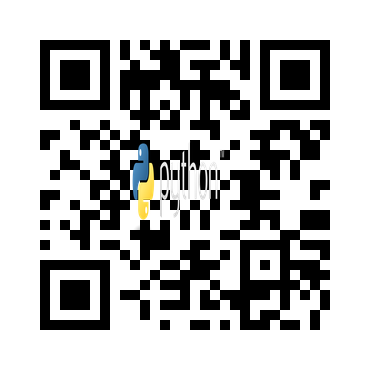

In [31]:
from IPython.display import Image, display
Image('python_qr_code.png')

# Using multiple tools at once

In [32]:
prompt = "Can you help me create a qr code that goes to https://react.dev/ from the image react-logo.png? Also write me a txt note with the current weather please."

response = client.chat.completions.create(
    model="openai:gpt-4o",
    messages=[
        {
            "role":"user",
            "content":prompt,
        }
    ],
    tools=[
        get_current_time,
        get_weather_from_ip,
        write_txt_file,
        generate_qr_code
    ],
    max_turns=5
)

print(response.choices[0].message.content)

The QR code has been created and saved as `react-logo.png.png` pointing to [https://react.dev/](https://react.dev/), and I've written the current weather information into a text file named `current_weather.txt`.


In [34]:
with open('current_weather.txt', 'r') as file:
    contents = file.read()
    print(contents)

Current: 30.4Â°C, High: 30.5Â°C, Low: 28.6Â°C


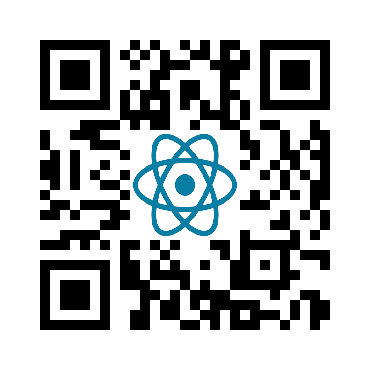

In [33]:
Image('react-logo.png.png')